# BW \#119 Python conferences

## Data and six questions
This week, we'll look at a small data set, one that aims to keep track of Python conferences around the world. The data is in a GitHub repo:

https://github.com/python-organizers/conferences

## Challenges
The learning goals include working with CSV files, dates and times, grouping, plotting and handling multiple files

- Download the GitHub Rep. Read the CSV file or each year into a single df. Make sure that all of the date related columns are `datetime` dtypes. 
- How many Python conferences are listed for each year ? Create a bar plot visualizing this information. Does anything stick out ? Find, starting in 2020, the 10 countries with the greates number of total conferenes. Create a bar plot comparing their numbers. 

In [1]:
!git clone https://github.com/python-organizers/conferences.git

Cloning into 'conferences'...


## Download the GitHub Rep. Read the CSV file or each year into a single df. Make sure that all of the date related columns are `datetime` dtypes. 


In [29]:
import pandas as pd
import glob

all_dfs = [pd.read_csv(file, parse_dates=['Start Date', 'End Date',
                                  'Tutorial Deadline',
                                  'Talk Deadline']) for file in glob.glob(r"C:\Users\npigeon1\Pandas-Bamboo-Weekly\BW #119 Python conferences\conferences\*.csv")]
df = pd.concat(all_dfs, ignore_index=True)
df.shape


(408, 11)

In [15]:
df.head()

,Subject,Start Date,End Date,Location,Country,Venue,Tutorial Deadline,Talk Deadline,Website URL,Proposal URL,Sponsorship URL
0,PyCon Belarus,2017-02-04,2017-02-04,"Minsk, Minsk, Belarus",BLR,NaN,NaN,NaN,http://by.pycon.org,NaN,http://by.pycon.org/assets/files/Call_for_Part...
1,PyCon Colombia,2017-02-10,2017-02-11,"Bogotá, Capital District, Colombia",COL,NaN,NaN,NaN,https://www.pycon.co,NaN,NaN
2,PyCon Pune,2017-02-16,2017-02-19,"Pune, Maharashtra, India",IND,NaN,NaN,NaN,https://pune.pycon.org,NaN,NaN
3,PyCon Philippines,2017-02-25,2017-02-26,"Cagayan de Oro, Misamis Oriental, Philippines",PHL,NaN,NaN,NaN,https://pycon.python.ph,NaN,NaN
4,PyCon Slovakia,2017-03-10,2017-03-10,"Bratislava, Bratislava, Slovakia",SVK,NaN,2017-02-14,2017-02-14,https://2017.pycon.sk,https://2017.pycon.sk/cfp,NaN


## How many Python conferences are listed for each year ? 

In [30]:
df.groupby(df['End Date'].dt.year)['Subject'].count()

End Date
2017    40
2018    58
2019    50
2020    35
2021    14
2022    25
2023    71
2024    68
2025    45
2026     2
Name: Subject, dtype: int64

## Create a bar plot visualizing this information.

<Axes: title={'center': 'Number of Python Conferences by Year'}, xlabel='End Date'>

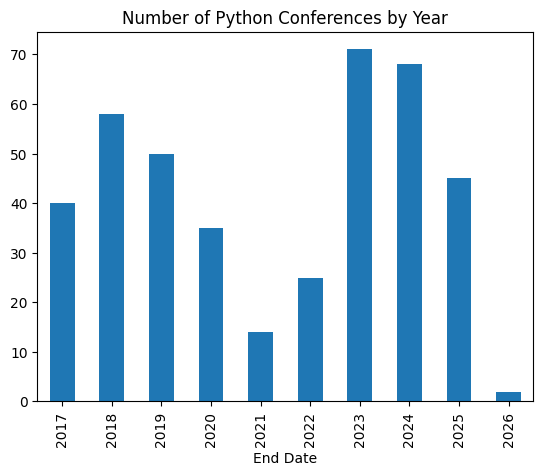

In [33]:
df.groupby(df['End Date'].dt.year)['Subject'].count().plot(kind='bar', title='Number of Python Conferences by Year')

## Does anything stick out ? Find, starting in 2020, the 10 countries with the greates number of total conferenes. 

In [42]:
df.sort_values(by='End Date')[df['End Date'].dt.year >= 2020].groupby('Country')['Subject'].count().nlargest(10)

C:\Users\npigeon1\AppData\Local\Temp\ipykernel_30120\2694518533.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df.sort_values(by='End Date')[df['End Date'].dt.year >= 2020].groupby('Country')['Subject'].count().nlargest(10)


Country
USA    49
DEU    13
CHE    10
JPN     9
RUS     9
BRA     7
GBR     7
AUS     6
CZE     6
ESP     6
Name: Subject, dtype: int64

In [48]:
(
    df.loc[lambda df_:df_['Start Date'].dt.year >= 2020]
      .groupby(pd.Grouper(key='Country'))['Subject'].count() # we use pd.Grouper because we groupby on a subset of df  
      .sort_values(ascending=False)
      .head(10)
)

Country
USA    49
DEU    13
CHE    10
RUS     9
JPN     9
GBR     7
BRA     7
ESP     6
CZE     6
AUS     6
Name: Subject, dtype: int64

## Create a bar plot comparing their numbers. 

<Axes: title={'center': 'Top 10 Countries with Most Python Conferences Since 2020'}, xlabel='Country'>

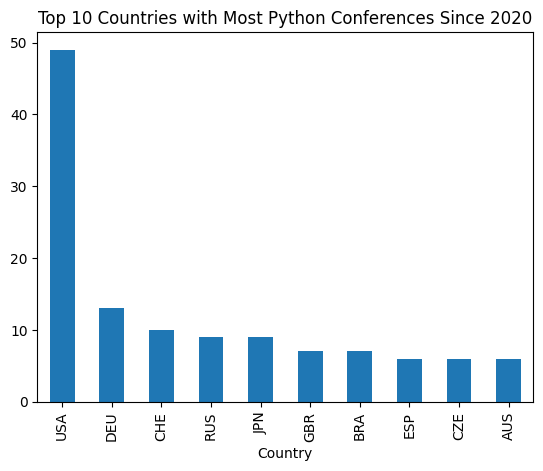

In [49]:
(
    df.loc[lambda df_:df_['Start Date'].dt.year >= 2020]
      .groupby(pd.Grouper(key='Country'))['Subject'].count() # we use pd.Grouper because we groupby on a subset of df  
      .sort_values(ascending=False)
      .head(10)
      .plot.bar(title='Top 10 Countries with Most Python Conferences Since 2020')
)